## Figure 4G with Theta. Phase of long theta and remote content

In [1]:
%reload_ext autoreload
%autoreload 2

In [121]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_remote_theta_dynamics_animal, time_to_phase, remote_phase
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta, MUATheta
from spyglass.shijiegu.load import load_run_sessions
from spyglass.shijiegu.changeOfMind import color_by_rat

In [114]:
list_of_days_animals = {}
encoding_set_animals = {}
classifier_param_name_animals = {}
seq_animals = {}
success_animal = {}

animal = 'eliot'
list_of_days_animals[animal] = ['20221018','20221019','20221021','20221022','20221023','20221024']
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'molly'
list_of_days_animals[animal] = ['20220418']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "lewis"
list_of_days_animals[animal] = ["20240107", "20240108","20240109",	"20240110","20240113"]
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

animal = "julio"
list_of_days_animals[animal] = ["20230801", "20230802","20230805","20230806"]
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "klein"
list_of_days_animals[animal] = ["20231101", "20231102", "20231105", "20231106", "20231107", "20231108", "20231109"]
seq_animals[animal] = 'rev2'
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

bad_sessions = [('eliot', '20221019', '10_Seq2Session5'),
               ('molly', '20220418', '06_Seq2Session3'),
               ('molly', '20220418', '08_Seq2Session4'),
               ('molly', '20220418', '10_Seq2Session5'),
               ('julio', '20230802', '02_Seq2Session1'),
               ('julio', '20230802', '04_Seq2Session2'),
               ('julio', '20230802', '06_Seq2Session3'),
               ('julio', '20230802', '08_Seq2Session4'),
               ('lewis', '20240113', '02_Rev2Session1'),
               ('klein', '20231101', '12_Rev2Session6')] # these sessions have incomplete number of sorted tetrodes

In [131]:
#%debug

In [150]:
r_phase_start_animal = {}
r_phase_end_animal = {}
l_phase_start_animal = {}
l_phase_end_animal = {}

sessions = []

for animal in ["eliot"]:
    r_phase_start_all = []
    r_phase_end_all = []
    l_phase_start_all = []
    l_phase_end_all = []
    
    for d in list_of_days_animals[animal]:
        nwb_copy_file_name = f"{animal}{d}_.nwb"
        run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)
        for session_name in run_session_names:
            if (animal, d, session_name) in bad_sessions:
                continue
            phase_start, phase_end = remote_phase(nwb_copy_file_name, session_name, long_flag = True)
            l_phase_start_all += phase_start
            l_phase_end_all += phase_end

            phase_start, phase_end = remote_phase(nwb_copy_file_name, session_name, long_flag = False)
            r_phase_start_all += phase_start
            r_phase_end_all += phase_end
            
            sessions.append((animal,d, session_name))
            
    l_phase_start_animal[animal] =l_phase_start_all
    l_phase_end_animal[animal] =l_phase_end_all

    r_phase_start_animal[animal] =r_phase_start_all
    r_phase_end_animal[animal] =r_phase_end_all
    

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
eliot20221018_ 1         01_Seq2Sleep1  pos 0 valid ti
eliot20221018_ 2         02_Seq2Session pos 1 valid ti
eliot20221018_ 3         03_Seq2Sleep2  pos 2 valid ti
eliot20221018_ 4         04_Seq2Session pos 3 valid ti
eliot20221018_ 5         05_Seq2Session pos 4 valid ti
eliot20221018_ 6         06_Seq2Sleep3  pos 5 valid ti
eliot20221018_ 7         07_Seq2Session pos 6 valid ti
eliot20221018_ 8         08_Seq2Sleep4  pos 7 valid ti
eliot20221018_ 9         09_Seq2Session pos 8 valid ti
eliot20221018_ 10        10_Seq2Sleep5  pos 9 valid ti
eliot20221018_ 11        11_Seq2Session pos 10 valid t
eliot20221018_ 12        12_Seq2Sleep6  pos 11 valid t
 (Total: 12)

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
eliot20221019_ 1         01_Seq2Sleep1  pos 0 valid ti
eliot20221019_ 2         02_Seq2Session pos 1 valid

### Phase histogram

In [151]:
def plot_polar_hist(angles, ax, animal, num_bins = 20):
    # 3. Calculate the histogram
    num_bins = 16
    hist_counts, bin_edges = np.histogram(angles, bins=num_bins, range=(0, 2 * np.pi), weights = np.ones(len(angles))/len(angles))

    # 4. Plot the histogram using ax.bar
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bar_width = np.diff(bin_edges)

    color = color_by_rat[animal.lower()]
    bars = ax.bar(bin_centers, hist_counts, width=bar_width, bottom=0.0, align='center', color=color, alpha = 0.5, edgecolor='black')

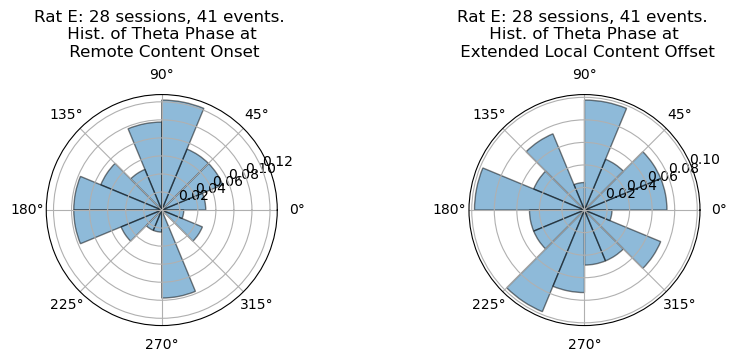

In [152]:
animal = 'eliot'

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize = (10,3))

#### 1. Onset
ax = axes[0]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = l_phase_start_animal[animal]
plot_polar_hist(angles, ax, animal, num_bins = 10)

ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Remote Content Onset', va='bottom')
ax.grid(True)

#### 2. Offset
ax = axes[1]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = l_phase_end_animal[animal]
plot_polar_hist(angles, ax, animal, num_bins = 20)

# 5. Customize the plot (optional)
ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Extended Local Content Offset', va='bottom')
ax.grid(True)

# You can further customize labels, tick marks, etc.

# 6. Display the plot
plt.savefig(f'longlocal_content_phase_{animal}.pdf',dpi=300,bbox_inches='tight')

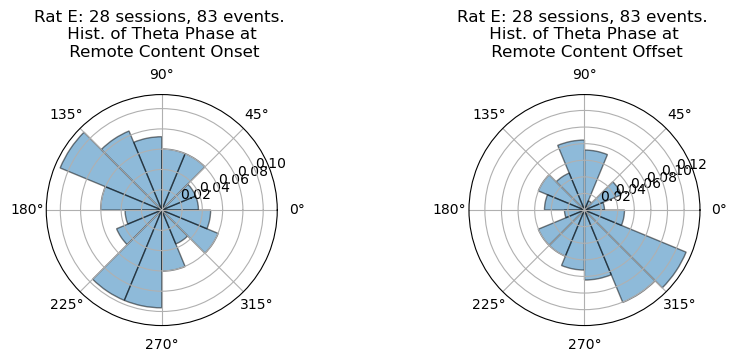

In [153]:
animal = 'eliot'

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize = (10,3))

#### 1. Onset
ax = axes[0]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = r_phase_start_animal[animal]
plot_polar_hist(angles, ax, animal, num_bins = 10)

ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Remote Content Onset', va='bottom')
ax.grid(True)

#### 2. Offset
ax = axes[1]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = r_phase_end_animal[animal]
plot_polar_hist(angles, ax, animal, num_bins = 20)

# 5. Customize the plot (optional)
ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Remote Content Offset', va='bottom')
ax.grid(True)

# You can further customize labels, tick marks, etc.

# 6. Display the plot
plt.savefig(f'remote_content_phase_{animal}.pdf',dpi=300,bbox_inches='tight')

In [128]:
MUATheta() & {"nwb_file_name": "lewis20240107_.nwb"}

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),"data_type sorted_pyramidal, unsorted_mua, sorted_all",theta_xr theta table
lewis20240107_.nwb,2,sorted_pyramidal,=BLOB=


### End here

In [23]:
pandas = (ChangeofMindRemoteTheta() & {"nwb_file_name":"eliot20221020_.nwb","epoch":4}).fetch1("pandas")

In [33]:
(ChangeofMindTheta() & {"nwb_file_name":"eliot20221020_.nwb","epoch":4})

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),proportion minimal amount of proportion the animal is in before it backed out,"delta_t_minus time in seconds, before change of mind that we look for theta decodes","delta_t_plus time in seconds, after change of mind that we look for theta decodes",max_flag,analysis_file_name name of the nwb analysis file,"pandas pandas dataframe saved as dictionary, choice"
eliot20221020_.nwb,4,0.1,0,2,0,eliot20221020_JODWDXPUN3.nwb,=BLOB=
eliot20221020_.nwb,4,0.1,5,5,1,,=BLOB=


In [35]:
pandas = (ChangeofMindTheta() & {"nwb_file_name":"eliot20221020_.nwb","epoch":4,
                                "delta_t_minus":5,
                                "delta_t_plus":5,
                                }).fetch1("pandas")

In [39]:
log_df = pd.DataFrame(pandas)
log_df

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,long_theta,theta_dev,long_theta_intervals,change_of_mind_num,...,proportion_arm2,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,current,future_H,future_O,past,past_reward
1,1.666287e+09,1.0,1.666287e+09,2.0,1.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,2.0,2.0,4.0,NaN,NaN
2,1.666287e+09,1.0,1.666287e+09,4.0,1.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,4.0,4.0,3.0,2.0,NaN
3,1.666287e+09,1.0,1.666287e+09,3.0,2.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,3.0,3.0,1.0,4.0,NaN
4,1.666287e+09,1.0,1.666287e+09,1.0,1.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,1.0,1.0,2.0,3.0,3.0
5,1.666287e+09,1.0,1.666287e+09,2.0,1.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,2.0,2.0,1.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,1.666289e+09,1.0,1.666289e+09,1.0,1.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,1.0,1.0,4.0,1.0,1.0
79,NaN,NaN,1.666289e+09,4.0,0.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,4.0,4.0,2.0,1.0,1.0
80,1.666289e+09,1.0,1.666289e+09,2.0,1.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,2.0,2.0,1.0,4.0,1.0
81,1.666289e+09,1.0,1.666289e+09,1.0,1.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,1.0,1.0,NaN,2.0,1.0


In [40]:
log_df[log_df.long_theta]
#log_df[log_df.has_remote_interval]

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,long_theta,theta_dev,long_theta_intervals,change_of_mind_num,...,proportion_arm2,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,current,future_H,future_O,past,past_reward


In [9]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/'

output_path = os.path.join(output_folder,f"{animal}_figure4G") #os.join(output_folder,plot_data_filename)
with open(output_path, 'rb') as file:
    loaded_data = pickle.load(file)
    print(f"Data successfully loaded from {output_path}")
        
(event_intervals, long_theta_intervals, event_info) = loaded_data["event_intervals"], loaded_data["long_theta_intervals"], loaded_data["event_info"]

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/eliot_figure4G


In [12]:
event_info

[(0, 'eliot20221019_.nwb', '06_Seq2Session3', 15),
 (1, 'eliot20221019_.nwb', '06_Seq2Session3', 15),
 (2, 'eliot20221019_.nwb', '08_Seq2Session4', 33),
 (3, 'eliot20221020_.nwb', '06_Seq2Session3', 44),
 (4, 'eliot20221020_.nwb', '06_Seq2Session3', 44),
 (5, 'eliot20221021_.nwb', '04_Seq2Session2', 29),
 (6, 'eliot20221021_.nwb', '04_Seq2Session2', 29),
 (7, 'eliot20221021_.nwb', '08_Seq2Session4', 60),
 (8, 'eliot20221023_.nwb', '06_Seq2Session3', 26),
 (9, 'eliot20221023_.nwb', '08_Seq2Session4', 63),
 (10, 'eliot20221024_.nwb', '06_Seq2Session4', 13),
 (11, 'eliot20221024_.nwb', '08_Seq2Session5', 58),
 (12, 'eliot20221024_.nwb', '10_Seq2Session6', 42),
 (13, 'eliot20221024_.nwb', '10_Seq2Session6', 48)]

## investigate remote events - start

In [7]:
loaded_data = load_remote_animal(
        animal,list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = 0.1, use_1d = 1)
    
(_, remote_info,
            remote_time_intervals, remote_arm_identities
                ) = (loaded_data['all_info_animal'], loaded_data['info_animal'],
                    loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/eliot_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221018_20221026_p0.1_use1d1.pkl':


In [272]:
ind = 6
print(remote_arm_identities[ind])
print(remote_info[ind])

[0]
['julio20230802_.nwb', '06_Seq2Session3', [51]]


In [275]:
#remote_arm_identities

In [273]:
remote_info

[['julio20230731_.nwb', '02_Seq2Session1', [22]],
 ['julio20230731_.nwb', '04_Seq2Session2', [12]],
 ['julio20230731_.nwb', '04_Seq2Session2', [15, 15]],
 ['julio20230801_.nwb', '06_Seq2Session3', [11, 11, 11, 11]],
 ['julio20230801_.nwb', '08_Seq2Session4', [9]],
 ['julio20230802_.nwb', '04_Seq2Session2', [70]],
 ['julio20230802_.nwb', '06_Seq2Session3', [51]],
 ['julio20230803_.nwb', '08_Seq2Session4', [51, 51, 51]],
 ['julio20230803_.nwb', '08_Seq2Session4', [80, 80]],
 ['julio20230803_.nwb', '10_Seq2Session5', [9, 9]],
 ['julio20230803_.nwb', '10_Seq2Session5', [57]],
 ['julio20230803_.nwb', '10_Seq2Session5', [69, 69, 69]],
 ['julio20230803_.nwb', '12_Seq2Session6', [13]],
 ['julio20230803_.nwb', '12_Seq2Session6', [52]],
 ['julio20230804_.nwb', '04_Seq2Session2', [70, 70]],
 ['julio20230804_.nwb', '12_Seq2Session6', [37]],
 ['julio20230805_.nwb', '02_Seq2Session1', [78]],
 ['julio20230805_.nwb', '04_Seq2Session2', [20]],
 ['julio20230805_.nwb', '04_Seq2Session2', [27, 27, 27, 27]

In [292]:
### long theta
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.changeOfMind_triggered import form_null_model, find_large_position_minus_decode_trials_lightweight

In [478]:
from spyglass.shijiegu.Analysis_SGU import DecodeResultsLinear

(DecodeResultsLinear & {
                        'nwb_file_name': "eliot20221019_.nwb"})

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,classifier_param_name a name for this set of parameters,encoding_set a name for this set of encoding,posterior posterior within that interval (1D)
eliot20221019_.nwb,02_Seq2Session1,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221019_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221019_.nwb,04_Seq2Session2,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221019_.nwb,04_Seq2Session2,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221019_.nwb,06_Seq2Session3,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221019_.nwb,06_Seq2Session3,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221019_.nwb,08_Seq2Session4,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221019_.nwb,08_Seq2Session4,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221019_.nwb,10_Seq2Session5,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221019_.nwb,10_Seq2Session5,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=


In [340]:
day = '20230808'#list_of_days_animals[animal]
session_name = "08_Seq2Session4"

In [341]:
nwb_file_name = animal.lower() + day + '.nwb'
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
print(nwb_copy_file_name)
session_interval, position_interval = runSessionNames(nwb_copy_file_name)

paramters = {"proportion": 0.1,
                     "delta_t_minus":5, "delta_t_plus":5,
                     "max_flag":1, "segment_only": False,
                     "segment_only": True,
                     "multiple_CoM":True, "single_CoM":True, "first_CoM":False,
                     }
        
loaded_data_segment = load_triggered_position_decode_day(animal, day, encoding_set_animals[animal], classifier_param_name_animals[animal],
                                                         control = False,
                                                         **paramters)
        
loaded_data_control = load_triggered_position_decode_day(animal, day, encoding_set_animals[animal], classifier_param_name_animals[animal],
                                                         control = True,
                                                         **paramters)
gaussian_process, _ , _2 = form_null_model(loaded_data_control["triggered_positions_baseoff"], loaded_data_control["triggered_decodes_baseoff"])

julio20230808_.nwb
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/julio_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20230808_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control0.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/julio_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20230808_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control1.pkl':


In [346]:
paramters = {"proportion": 0.1,
                         "delta_t_minus":5, "delta_t_plus":5,
                         "max_flag":1, "segment_only": False,
                          "multiple_CoM":True, "single_CoM":True, "first_CoM":False,
                         "control": False
                         }
        
loaded_data = load_triggered_position_decode_day(animal, day, encoding_set, classifier_param_name,
                                            **paramters)

triggered_positions, triggered_positions_abs, triggered_trial_infos = (
                    loaded_data["triggered_positions_baseoff"],
                    loaded_data["triggered_positions"],
                    loaded_data["triggered_trial_info"],
            )

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/julio_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20230808_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control0_allposterior.pkl':


In [326]:
# load decode
from spyglass.shijiegu.load import load_decode
from spyglass.shijiegu.ripple_add_replay import select_subset_helper

encoding_set = encoding_set_animals[animal]
classifier_param_name = classifier_param_name_animals[animal]
decode = load_decode(nwb_copy_file_name,session_name,classifier_param_name,encoding_set)


In [344]:
from spyglass.shijiegu.Analysis_SGU import DecodeIngredients,ChangeofMind
import pandas as pd

entry = DecodeIngredients & {'nwb_file_name':nwb_copy_file_name,
                             'interval_list_name':session_name}
# position_1d,position_2d,
position_1d = pd.read_csv(entry.fetch1('position_1d')) #still need 1D position
position_2d = pd.read_csv(entry.fetch1('position_2d')) # need 2D position
            
# load ChangeofMind info
key={'nwb_file_name':nwb_copy_file_name,'epoch':session_name[:2],'proportion': 0.1}
print(ChangeofMind & key)
log = ChangeofMind().fetch1_dataframe(key)

[2025-10-30 14:46:45,630][WARNING]: Skipped checksum for file with hash: 4c3bb2a6-7842-14bc-b264-b7c2c4e806ac, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_8CM7Q91QU4.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
julio20230808_ 8         0.1            julio20230808_ 8518c31f-5ad5-
 (Total: 1)



In [299]:
(triggered_positions_abs2, triggered_positions_zeroed2,
         triggered_trial_infos2, triggered_decode2) = (
                    loaded_data_segment["triggered_positions_baseoff"],
                    loaded_data_segment["triggered_positions"],
                    loaded_data_segment["triggered_trial_info"],
                    loaded_data_segment["triggered_decodes_baseoff"]
            )

In [300]:
for ind in range(len(triggered_trial_infos2)):
    if triggered_trial_infos2[ind][0] == 'julio20230808_.nwb' and triggered_trial_infos2[ind][2] == 27:
        break
print(ind)

6


In [302]:
triggered_trial_infos2[6]

('julio20230808_.nwb', '08_Seq2Session4', 27, 3)

In [360]:
for remote_ind3 in range(len(triggered_trial_infos)):
    if triggered_trial_infos[remote_ind3][0] == 'julio20230808_.nwb' and triggered_trial_infos[remote_ind3][2] == 27:
        break
print(remote_ind3)
print(triggered_trial_infos[remote_ind3])
#triggered_positions, triggered_positions_abs, triggered_trial_infos

8
('julio20230808_.nwb', '08_Seq2Session4', 27, 3)


In [318]:
for remote_ind in range(len(remote_info)):
    if remote_info[remote_ind][0] == 'julio20230808_.nwb' and int(remote_info[remote_ind][2][0]) == 27:
        break
print(remote_ind)
print(remote_info[remote_ind])

28
['julio20230808_.nwb', '08_Seq2Session4', [27]]


In [321]:
positions = triggered_positions_abs2[ind]
decodes = triggered_decode2[ind]
flag, interval_long_theta = find_large_position_minus_decode_trials_lightweight(
                        gaussian_process, [positions], [decodes], minimum_duration = 0.02)

#interval_remote = remote_time_intervals[remote_ind]

In [465]:
from spyglass.shijiegu.changeOfMind_remote_interval import find_remote_theta_interval

(triggered_position, triggered_position_abs, triggered_trial_info) = (
    triggered_positions[remote_ind3], triggered_positions_abs[remote_ind3], triggered_trial_infos[remote_ind3])

(trial, interval_remote, replayed_arm_identity) = find_remote_theta_interval(
                    triggered_position, triggered_position_abs, triggered_trial_info,
                    decode, log, position_1d, position_2d,
                    1,use_home = False, use_outer = True, use_center = False, minimum_duration = 0.04)

In [368]:
#going inside find_remote_theta_interval
position_axis = np.array(decode.coords['position'])
        
# find the arm the animal is at
subset_arm = triggered_trial_info[-1] + 5
    
    # find the trial
    # find t0, t1 to consider
trialID = triggered_trial_info[2]
(t0, t1) = (triggered_position.index[0],triggered_position.index[-1])

In [414]:
from spyglass.shijiegu.changeOfMind_triggered import region,linear_map
from ripple_detection.core import segment_boolean_series
from spyglass.shijiegu.ripple_add_replay import find_start_end,position_posterior2arm_posterior
from spyglass.shijiegu.changeOfMind_remote_interval import linear2arm_including_home

In [405]:
position2d_subset = position_2d[np.logical_and(position_2d.time>=t0, position_2d.time<=t1)]
position1d_subset = position_1d[np.logical_and(position_1d.time>=t0, position_1d.time<=t1)]
decode_subset = select_subset_helper(decode,(t0,t1))

subset_ind = position1d_subset.track_segment_id == subset_arm
position2d_subset = position2d_subset[subset_ind]
position1d_subset = position1d_subset[subset_ind]
decode_subset = decode_subset.isel(time = np.argwhere(subset_ind).ravel())
posterior_position_subset = decode_subset.causal_posterior.sum(dim='state')
max_posterior_position = np.array(position_axis[posterior_position_subset.argmax(dim = 'position')])

is_remote = np.zeros_like(max_posterior_position) #just to initialize
for k in region.keys():
    if k == int(subset_arm):
        continue
    (arm_base, arm_top) = region[k]
    is_remote = is_remote + np.logical_and(max_posterior_position <= arm_top, max_posterior_position >= arm_base)
# find remote representation at home
is_remote = is_remote + np.logical_and(max_posterior_position >= 0, max_posterior_position <= linear_map[0][1])

is_moving = np.array(position2d_subset.head_speed) > 4
min_len = np.min([len(is_moving),len(is_remote)])
# choose min because one variable is a subset of decode and the other is a subset of position.
# there could be 1 or 2 time point difference.
is_moving = is_moving[:min_len]
is_remote = is_remote[:min_len]
    
is_remote = np.logical_and(is_remote, is_moving)

is_remote_pd = pd.Series(is_remote, index = posterior_position_subset.time)
is_remote_segments = np.array(segment_boolean_series(
        is_remote_pd, minimum_duration=0.02))

In [406]:
is_remote_segments

array([[1.69152977e+09, 1.69152977e+09],
       [1.69152977e+09, 1.69152977e+09],
       [1.69152977e+09, 1.69152977e+09],
       [1.69152977e+09, 1.69152977e+09]])

In [444]:
i = 1
(t0,t1) = is_remote_segments[i]
        
# restrict to continuous state:
#    length of the continuous state should be greater than 20ms
decode_subset_ = select_subset_helper(decode_subset,(t0,t1))
state_subset = np.array(decode_subset_.acausal_posterior.sum(dim='position'))
time=np.array(decode_subset_.acausal_posterior.time)
        
snippets_conti = find_start_end(state_subset[:,0]>0.5) #continuous
snippets = [time[s] for s in snippets_conti if np.diff(time[s])[0]>0.02]

In [445]:
#state_subset

In [446]:
s = 0
(t0_peak,t1_peak) = snippets[s]
            
# overall sum of decode posterior in the max posterior arm should be greater than 0.2
posterior_by_arm = position_posterior2arm_posterior(
                select_subset_helper(posterior_position_subset,snippets[s]),
                linear_map)
            
# classify the max/mean posterior arm, exclude the arm the animal is physically at
subset_ind = (posterior_position_subset.time >= t0_peak) & (posterior_position_subset.time <= t1_peak)
subset_arm_snippet = linear2arm_including_home(max_posterior_position[subset_ind])
subset_arm_snippet
subset_arm_snippet = np.mode(subset_arm_snippet[~np.isnan(subset_arm_snippet)])
            
#
subset_arm_snippet = np.setdiff1d(subset_arm_snippet,subset_arm)
            

In [452]:
subset_arm_snippet = linear2arm_including_home(max_posterior_position[subset_ind])

In [459]:
from scipy import stats
mode, count = stats.mode(subset_arm_snippet[~np.isnan(subset_arm_snippet)])
count >= (len(subset_arm_snippet) * 0.8)

[15:27:57][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


True

In [440]:
max_arm_ind = int(np.unique(subset_arm_snippet) - 5)

In [461]:
subset_arm

8

In [442]:
#decode_subset_.acausal_posterior.sum(dim='position')

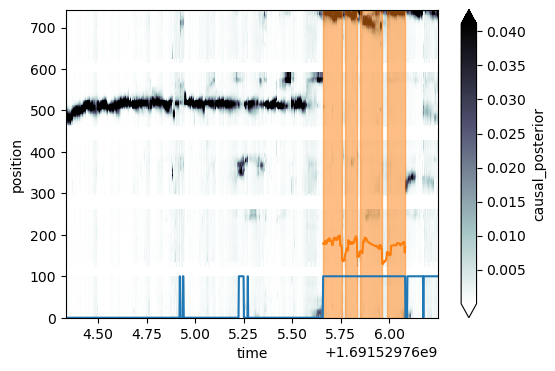

In [443]:
fig, axes = plt.subplots(1,1,figsize = (6, 4))


posterior_position_subset.plot(x='time', y='position', ax=axes, rasterized=True, robust=True, cmap='bone_r')
axes.plot(position1d_subset.time, is_remote*100)
axes.plot(decode_subset_.time, 100 + state_subset[:,0]*100)

# 2. find max decode location during that interval
for sg in snippets:
    axes.axvspan(sg[0],sg[1],color = 'C1',alpha = 0.5)

In [376]:
position1d_subset

,time,linear_position,track_segment_id,projected_x_position,projected_y_position
343637,1.691530e+09,1.773974,0.0,210.373109,232.230303
343638,1.691530e+09,1.773974,0.0,210.373109,232.230303
343639,1.691530e+09,1.773974,0.0,210.373109,232.230303
343640,1.691530e+09,1.773974,0.0,210.373109,232.230303
343641,1.691530e+09,1.773974,0.0,210.373109,232.230303
...,...,...,...,...,...
347540,1.691530e+09,664.499573,9.0,239.848965,145.039916
347541,1.691530e+09,664.534985,9.0,239.880823,145.024454
347542,1.691530e+09,664.570397,9.0,239.912681,145.008992
347543,1.691530e+09,664.599457,9.0,239.938824,144.996303


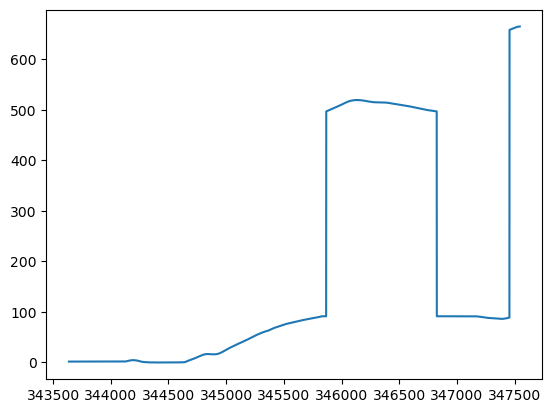

In [377]:
plt.plot(position1d_subset.linear_position)

0.09599995613098145
0.06200003623962402
0.11399984359741211
0.09400010108947754
0.029999971389770508


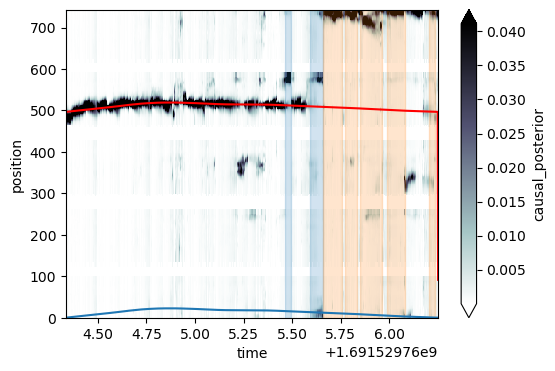

In [467]:
fig, axes = plt.subplots(1,1,figsize = (6, 4))

t0,t1 = positions.index[0], positions.index[-1]
decode_subset = select_subset_helper(decode,(t0,t1))
posterior_position_subset = decode_subset.causal_posterior.sum(dim='state') #causal decoder

posterior_position_subset.plot(x='time', y='position', ax=axes, rasterized=True, robust=True, cmap='bone_r')
# 2. find max decode location during that interval
posterior_position_subset = decode_subset.causal_posterior.sum(dim='state') #causal decoder

plt.plot(positions)
plt.plot(triggered_position, color = 'r')
for intvl in interval_long_theta:
    plt.axvspan(intvl[0],intvl[1],color = 'C0',alpha = 0.2)
for intvl in interval_remote:
    print(intvl[1]-intvl[0])
    plt.axvspan(intvl[0],intvl[1],color = 'C1',alpha = 0.2)

## investigate remote events - end

In [500]:
#list_of_days_animals

In [31]:
success = {}
for animal in ["molly"]:#["lewis","julio","klein"]:
    event_intervals, long_theta_intervals, event_info = find_remote_theta_dynamics_animal(animal,list_of_days_animals[animal],
                                                        classifier_param_name_animals[animal],encoding_set_animals[animal],
                                                        proportion = 0.1, use_1d = 1,
                                                        delta_t_minus = 5,delta_t_plus = 5,
                                                        multiple_CoM = True, single_CoM = True, first_CoM = False,
                                                        max_flag = True)
    
    output_folder = '/stelmo/shijie/change_of_mind_analysis/'
    data = {}
    data["event_intervals"], data["long_theta_intervals"], data["event_info"] = (event_intervals, long_theta_intervals, event_info)
    
    output_path = os.path.join(output_folder,f"{animal}_figure4G") #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved.")
        
    success[animal] = 1

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/molly_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_20220420_p0.1_use1d1.pkl':
molly20220416_.nwb
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control0_allposterior.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control0.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control1.pkl':


[2025-11-06 14:19:18,647][WARNING]: Skipped checksum for file with hash: 0c96e86a-0de2-4de8-92a3-1e4c889badc8, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_JI0W7A8PWE.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id      pandas    
+------------+ +-------+ +------------+ +------------+ +------------+ +--------+
molly20220416_ 2         0.1            molly20220416_ cd3bf88f-ed85- =BLOB=    
 (Total: 1)



[2025-11-06 14:19:27,782][WARNING]: Skipped checksum for file with hash: 90096c03-312a-ed49-cc4f-9ece7d1bb273, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_6L0KQZ610F.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id      pandas    
+------------+ +-------+ +------------+ +------------+ +------------+ +--------+
molly20220416_ 4         0.1            molly20220416_ 2b427aa0-e77c- =BLOB=    
 (Total: 1)



...

*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id      pandas    
+------------+ +-------+ +------------+ +------------+ +------------+ +--------+
molly20220420_ 8         0.1            molly20220420_ a6130b95-668d- =BLOB=    
 (Total: 1)



[2025-11-06 14:23:50,231][WARNING]: Skipped checksum for file with hash: 578b2c0b-1ac0-295b-272c-4cc00942f80a, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_NYTR0UJN9I.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id      pandas    
+------------+ +-------+ +------------+ +------------+ +------------+ +--------+
molly20220420_ 10        0.1            molly20220420_ cb72e620-b000- =BLOB=    
 (Total: 1)



[2025-11-06 14:23:59,284][WARNING]: Skipped checksum for file with hash: 7cc58234-ca12-b517-0a5f-a0b5b3650837, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_UXBQRKDEWZ.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id      pandas    
+------------+ +-------+ +------------+ +------------+ +------------+ +--------+
molly20220420_ 12        0.1            molly20220420_ 39e5a5ea-53f7- =BLOB=    
 (Total: 1)

Data successfully pickled and saved.


In [502]:
success

{'lewis': 1, 'julio': 1, 'klein': 1}

In [37]:
animal = "klein"

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/klein_figure4G


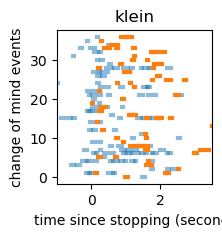

In [38]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/'

output_path = os.path.join(output_folder,f"{animal}_figure4G") #os.join(output_folder,plot_data_filename)
with open(output_path, 'rb') as file:
    loaded_data = pickle.load(file)
    print(f"Data successfully loaded from {output_path}")
        
(event_intervals, long_theta_intervals, event_info) = loaded_data["event_intervals"], loaded_data["long_theta_intervals"], loaded_data["event_info"]
    
fig, axes = plt.subplots(1,1,figsize = (2, 2))

for event in long_theta_intervals:
    y, x = event
    axes.plot(x,[y,y], color = 'C0', alpha = 0.5, linewidth = 3)
    
for event in event_intervals:
    y, x = event
    axes.plot(x,[y,y], color = 'C1', linewidth = 3)


axes.set_ylabel("change of mind events")
axes.set_xlabel("time since stopping (second)")
axes.set_xlim([-1,3.5])
axes.set_title(animal)

plt.savefig(f'time_course_event_by_event{animal}.pdf',dpi=300,bbox_inches='tight')

### remote triggered histogram

In [39]:
interval_to_consider = np.arange(-2,2,0.04)

all_events = np.unique([e[0] for e in event_intervals])

remote_counter = np.zeros_like(interval_to_consider)
longtheta_counter = np.zeros_like(interval_to_consider)

t0t1 = None
for eventID in all_events:
    # find all remote events with that eventID
    remote_events = [e for e in event_intervals if e[0] == eventID]

    # find all long theta with that eventID
    long_theta_events = [e for e in long_theta_intervals if e[0] == eventID]

    t0 = long_theta_events[0][1][0]

    # for each event align by t0
    for event in remote_events:

        t0t1 = event[1]
        
        times = np.arange(t0t1[0], t0t1[1], 0.01)# - t0
        bins = np.digitize(times, interval_to_consider)
        remote_counter[bins-1] += 1

    for event in long_theta_events:

        t0t1 = event[1]
        #print(t0t1)
        times = np.arange(t0t1[0], t0t1[1], 0.01)# - t0
        bins = np.digitize(times, interval_to_consider)
        longtheta_counter[bins-1] += 1
        
remote_counter = remote_counter / len(all_events)
longtheta_counter = longtheta_counter / len(all_events)

Text(0.5, 1.0, 'klein')

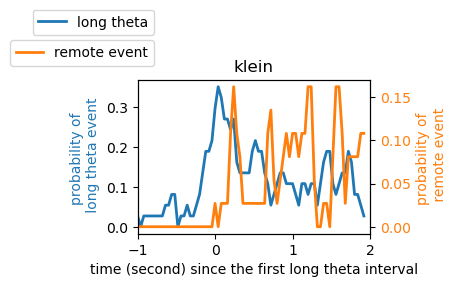

In [40]:
fig, ax1 = plt.subplots(1,1,figsize = (3, 2))
ax1.plot(interval_to_consider[:-1], np.clip(longtheta_counter[:-1],0,1),  color = 'C0', linewidth = 2, label = 'long theta')

ax1.set_xlabel("time (second) since the first long theta interval")
ax1.set_ylabel("probability of \n long theta event",color='C0')

ax2 = ax1.twinx()
ax2.plot(interval_to_consider[:-1], remote_counter[:-1], color = 'C1', linewidth = 2, label = 'remote event')
ax2.set_ylabel('probability of \n remote event', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#ax1.set_ylim([0,1])
ax1.set_xlim([-1,2])
ax2.set_xlim([-1,2])
#ax2.set_ylim([0,1])
ax1.legend(bbox_to_anchor=(0.1, 1.5))
ax2.legend(bbox_to_anchor=(0.1, 1.3))
ax1.set_title(animal)

In [41]:
def std_error_proportion(p,N):
    return np.sqrt(p*(1-p)/N)

In [42]:
interval_to_consider = np.arange(-2,2,0.04)

all_events = np.unique([e[0] for e in event_intervals])

remote_counter = np.zeros_like(interval_to_consider)
longtheta_counter = np.zeros_like(interval_to_consider)

t0t1 = None
for eventID in all_events:
    # find all remote events with that eventID
    remote_events = [e for e in event_intervals if e[0] == eventID]

    # find all long theta with that eventID
    long_theta_events = [e for e in long_theta_intervals if e[0] == eventID]

    t0 = remote_events[0][1][0]

    # for each event align by t0
    for event in remote_events:

        t0t1 = event[1]
        
        times = np.arange(t0t1[0], t0t1[1], 0.01) - t0
        bins = np.digitize(times, interval_to_consider)
        remote_counter[bins-1] += 1

    for event in long_theta_events:

        t0t1 = event[1]
        #print(t0t1)
        times = np.arange(t0t1[0], t0t1[1], 0.01) - t0
        bins = np.digitize(times, interval_to_consider)
        longtheta_counter[bins-1] += 1
        
remote_counter = remote_counter / len(all_events)
longtheta_counter = longtheta_counter / len(all_events)
N = len(all_events)
sd_error_remote_counter = std_error_proportion(remote_counter, N)
sd_error_longtheta_counter = std_error_proportion(longtheta_counter, N)

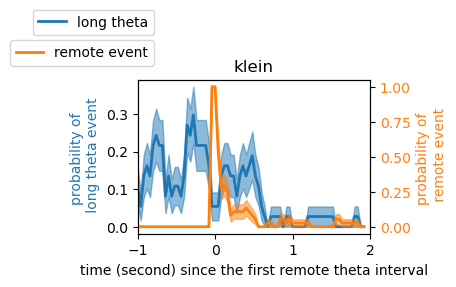

In [43]:
fig, ax1 = plt.subplots(1,1,figsize = (3, 2))
x = interval_to_consider[:-1]
y = np.clip(longtheta_counter[:-1],0,1)
yerr = sd_error_longtheta_counter[:-1]

ax1.plot(x, y,  color = 'C0', linewidth = 2, label = 'long theta')
ax1.fill_between(x, y - yerr, y + yerr, color = 'C0', alpha = 0.5)

ax1.set_xlabel("time (second) since the first remote theta interval")
ax1.set_ylabel("probability of \n long theta event",color='C0')

ax2 = ax1.twinx()

y = np.clip(remote_counter[:-1],0,1)
yerr = sd_error_remote_counter[:-1]

ax2.plot(x, y, color = 'C1', linewidth = 2, label = 'remote event')
ax2.fill_between(x, y - yerr, y + yerr, color = 'C1', alpha = 0.5)
ax2.set_ylabel('probability of \n remote event', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

ax1.set_xlim([-1,2])
ax2.set_xlim([-1,2])
#ax2.set_ylim([0,1])
ax1.legend(bbox_to_anchor=(0.1, 1.5))
ax2.legend(bbox_to_anchor=(0.1, 1.3))
ax1.set_title(animal)

plt.savefig(f'theta_time_course_{animal}.pdf',dpi=300,bbox_inches='tight')

In [78]:
long_theta_interval

[(0, array([0.26799989, 0.68400002])),
 (0, array([0.74799967, 0.85999942])),
 (1, array([0.25199962, 0.32199979])),
 (1, array([0.37799978, 0.4599998 ])),
 (1, array([0.59599972, 0.76199985])),
 (1, array([0.79399967, 0.87399983])),
 (1, array([1.04999924, 1.09399962])),
 (2, array([0.23799992, 0.32399988])),
 (2, array([2.28399897, 2.52799892])),
 (2, array([2.55399895, 2.61199903])),
 (2, array([2.63799906, 2.7519989 ])),
 (2, array([3.32799864, 3.40599871])),
 (2, array([0.23799992, 0.32399988])),
 (2, array([2.28399897, 2.52799892])),
 (2, array([2.55399895, 2.61199903])),
 (2, array([2.63799906, 2.7519989 ])),
 (2, array([3.32799864, 3.40599871])),
 (3, array([0.23799992, 0.32399988])),
 (3, array([2.28399897, 2.52799892])),
 (3, array([2.55399895, 2.61199903])),
 (3, array([2.63799906, 2.7519989 ])),
 (3, array([3.32799864, 3.40599871])),
 (3, array([0.23799992, 0.32399988])),
 (3, array([2.28399897, 2.52799892])),
 (3, array([2.55399895, 2.61199903])),
 (3, array([2.63799906, 2

### End here

In [45]:
loaded_data = load_remote_animal_figure4(
        animal, list_of_days_animals[animal],encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = 0.1, use_1d = 1)

remote_info, remote_time_intervals = loaded_data['info_animal'], loaded_data['time_intervals_animal']

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240110_p0.1_use1d1.pkl':


In [59]:
remote_time_intervals[2][0][-1]

1704481574.316091

In [60]:
remote_time_intervals[3][0][-1]

1704481574.316091

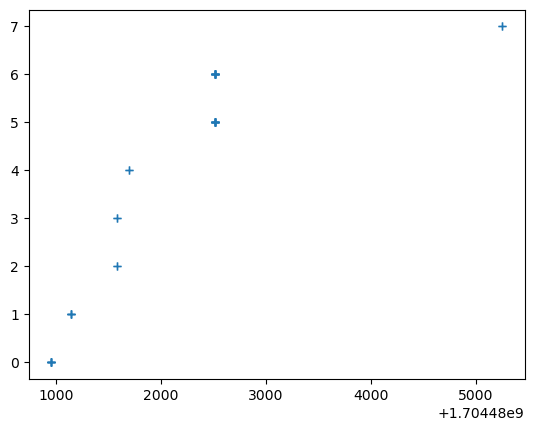

In [54]:
ind = 0
for intervals in remote_time_intervals[:8]:
    for interval in intervals:
        x = interval
        y = ind
        plt.plot(x, [y, y], '+', color = 'C0')
    ind += 1

In [62]:
paramters = {"proportion": 0.1,
             "delta_t_minus":5, "delta_t_plus":5,
             "max_flag":1, "segment_only": False,
             "multiple_CoM":1, "single_CoM":1, "first_CoM":0,
             "control": 0}
        
loaded_data = load_triggered_position_decode_day(animal, list_of_days_animals[animal][0], encoding_set_animals[animal],
                                                 classifier_param_name_animals[animal],
                                                 **paramters)

triggered_positions, triggered_positions_abs, triggered_trial_infos = (
                    loaded_data["triggered_positions_baseoff"],
                    loaded_data["triggered_positions"],
                    loaded_data["triggered_trial_info"])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/lewis_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control0_allposterior.pkl':


In [64]:
triggered_positions[0]

time
1.704480e+09      1.891575
1.704480e+09      1.891706
1.704480e+09      1.891838
1.704480e+09      1.891969
1.704480e+09      1.892101
                   ...    
1.704480e+09    418.292280
1.704480e+09    418.292280
1.704480e+09    418.292280
1.704480e+09    418.292280
1.704480e+09    418.292280
Length: 5001, dtype: float64

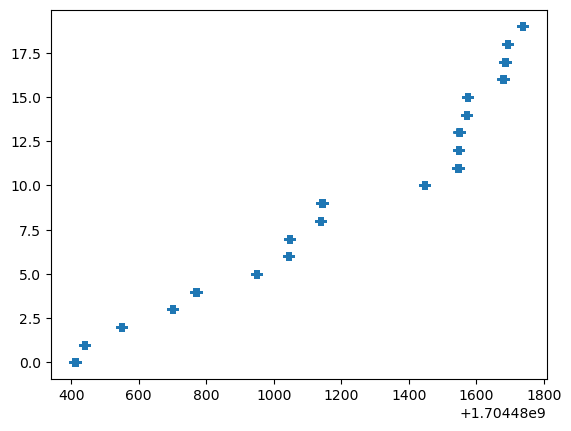

In [72]:
ind = 0
for intervals in triggered_positions[:20]:
    interval = intervals.index
    x = interval
    y = ind + np.zeros_like(interval)
    plt.plot(x, y, '+', color = 'C0')
    ind += 1

In [75]:
ind1 = 8
ind2 = 9
print(triggered_positions[ind1].index[0],triggered_positions[ind1].index[-1])
print(triggered_positions[ind2].index[0],triggered_positions[ind2].index[-1])

1704481133.1982584 1704481143.1982546
1704481137.3222568 1704481147.322253


In [73]:
triggered_positions[9].index[0]

1704481137.3222568

[15:47:38][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:47:38][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Text(0.5, 1.0, 'lewis')

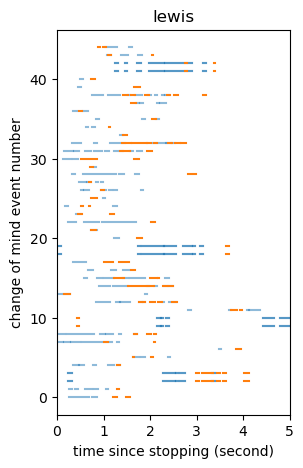

In [41]:
fig, axes = plt.subplots(1,1,figsize = (3, 5))

for event in long_theta_interval:
    y, x = event
    axes.plot(x,[y,y], color = 'C0', alpha = 0.5)
    
for event in event_intervals:
    y, x = event
    axes.plot(x,[y,y], color = 'C1')


axes.set_ylabel("change of mind event number")
axes.set_xlabel("time since stopping (second)")
axes.set_xlim([0,5])
axes.set_title(animal)

(0.0, 5.0)

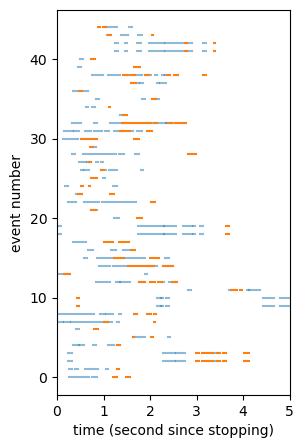

In [37]:
fig, axes = plt.subplots(1,1,figsize = (3, 5))

for event in long_theta_interval:
    y, x = event
    axes.plot(x,[y,y], color = 'C0', alpha = 0.5)
    
for event in event_intervals:
    y, x = event
    axes.plot(x,[y,y], color = 'C1')


axes.set_ylabel("change of mind event number")
axes.set_xlabel("time since stopping (second)")
axes.set_xlim([0,5])
axes.set_title(animal)

In [6]:
loaded_data = load_remote_animal_figure4(
        animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = 0.1, use_1d = 1)
    
(all_info_animal, info_animal,
        time_intervals_animal, arm_identities_animal
            ) = (loaded_data['all_info_animal'], loaded_data['info_animal'],
                loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240110_p0.1_use1d1.pkl':


In [11]:
paramters = {"proportion": 0.1,
                         "delta_t_minus":5, "delta_t_plus":5,
                         "max_flag":1, "segment_only": False,
                          "multiple_CoM":1, "single_CoM":1, "first_CoM":False,
                         "control": False
                         }
        
loaded_data = load_triggered_position_decode_day(animal, list_of_days_animals[animal][0], encoding_set_animals[animal], classifier_param_name_animals[animal],
                                                 **paramters)

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/lewis_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control0_allposterior.pkl':


In [23]:
triggered_positions_abs, triggered_positions_zeroed, triggered_trial_infos = (
                    loaded_data["triggered_positions_baseoff"],
                    loaded_data["triggered_positions"],
                    loaded_data["triggered_trial_info"],
            )

In [24]:
triggered_position = triggered_positions_abs[0]
triggered_position_zeroed = triggered_positions_zeroed[0]

In [28]:
len(triggered_position_zeroed)

5001

In [38]:
np.array(triggered_position.iloc[np.argwhere(triggered_position_zeroed.index == 0).ravel()].index)

array([1.70448041e+09])

array([2500])

In [ ]:
triggered_trial_infos

In [22]:
# loop through all trials in triggered_trial_infos
# find the corresponding entries in the remote tally, if any, there might be 2-3 on that trial
# for each C-o-M event, advance event number by 1, add intervals

[('lewis20240105_.nwb', '02_Rev2Session1', 19, 3),
 ('lewis20240105_.nwb', '02_Rev2Session1', 20, 3),
 ('lewis20240105_.nwb', '02_Rev2Session1', 25, 4),
 ('lewis20240105_.nwb', '02_Rev2Session1', 31, 3),
 ('lewis20240105_.nwb', '02_Rev2Session1', 34, 2),
 ('lewis20240105_.nwb', '02_Rev2Session1', 42, 1),
 ('lewis20240105_.nwb', '02_Rev2Session1', 46, 2),
 ('lewis20240105_.nwb', '02_Rev2Session1', 46, 1),
 ('lewis20240105_.nwb', '02_Rev2Session1', 50, 1),
 ('lewis20240105_.nwb', '02_Rev2Session1', 50, 3),
 ('lewis20240105_.nwb', '02_Rev2Session1', 62, 2),
 ('lewis20240105_.nwb', '02_Rev2Session1', 65, 1),
 ('lewis20240105_.nwb', '02_Rev2Session1', 65, 3),
 ('lewis20240105_.nwb', '02_Rev2Session1', 65, 2),
 ('lewis20240105_.nwb', '02_Rev2Session1', 66, 2),
 ('lewis20240105_.nwb', '02_Rev2Session1', 66, 2),
 ('lewis20240105_.nwb', '02_Rev2Session1', 70, 2),
 ('lewis20240105_.nwb', '02_Rev2Session1', 70, 1),
 ('lewis20240105_.nwb', '02_Rev2Session1', 70, 1),
 ('lewis20240105_.nwb', '02_Rev

In [8]:
info_animal

[['lewis20240105_.nwb', '02_Rev2Session1', [42, 42, 42]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [50, 50]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [66]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [66]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [70]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [98, 98, 98, 98, 98]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [98, 98, 98, 98, 98]],
 ['lewis20240105_.nwb', '04_Rev2Session2', [9]],
 ['lewis20240105_.nwb', '06_Rev2Session3', [22, 22]],
 ['lewis20240105_.nwb', '08_Rev2Session4', [16]],
 ['lewis20240105_.nwb', '08_Rev2Session4', [20, 20]],
 ['lewis20240106_.nwb', '02_Rev2Session1', [39]],
 ['lewis20240106_.nwb', '04_Rev2Session2', [71, 71]],
 ['lewis20240106_.nwb', '06_Rev2Session3', [44]],
 ['lewis20240106_.nwb', '08_Rev2Session4', [13, 13, 13]],
 ['lewis20240106_.nwb', '08_Rev2Session4', [18]],
 ['lewis20240107_.nwb', '02_Rev2Session1', [47]],
 ['lewis20240107_.nwb', '02_Rev2Session1', [47]],
 ['lewis20240107_.nwb', '06_Rev2Sessi

In [7]:
time_intervals_animal

[[array([1.70448095e+09, 1.70448095e+09]),
  array([1.70448095e+09, 1.70448095e+09]),
  array([1.70448095e+09, 1.70448095e+09])],
 [array([1.70448114e+09, 1.70448114e+09]),
  array([1.70448114e+09, 1.70448114e+09])],
 [array([1.70448157e+09, 1.70448157e+09])],
 [array([1.70448157e+09, 1.70448157e+09])],
 [array([1.70448169e+09, 1.70448169e+09])],
 [array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09])],
 [array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09])],
 [array([1.70448525e+09, 1.70448525e+09])],
 [array([1.70448949e+09, 1.70448949e+09]),
  array([1.70448949e+09, 1.70448949e+09])],
 [array([1.70449394e+09, 1.70449394e+09])],
 [array([1.70449407e+09, 1.70449407e+09]),
 